In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

==========Data Exploration==========

In [55]:
df = pd.read_csv('data/healthcare-dataset-stroke-data.csv')
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [56]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 5110
Number of columns: 12


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [58]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [59]:
df = df.drop(columns='id')

In [60]:
label_columns = []
for col in df.columns:
    if df[col].dtype == object:
        print(df[col].value_counts())
        print()
        if df[col].nunique() == 2:
            label_columns.append(col)

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



In [61]:
ind = df[df['gender'] == 'Other'].index
df.drop(index=ind, inplace=True)
print(df['gender'].value_counts())
label_columns.append('gender')

gender
Female    2994
Male      2115
Name: count, dtype: int64


In [62]:
LE = LabelEncoder()
for col in label_columns:
    df[col] = LE.fit_transform(df[col])

In [63]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1
2,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
3,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
4,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1


In [64]:
one_hot_columns = [col for col in df.columns if df[col].dtype == object and df[col].nunique() > 2]
df = pd.get_dummies(df,columns=one_hot_columns)
df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,False,False,True,False,False,False,True,False,False
1,0,61.0,0,0,1,0,202.21,NaN,1,False,False,False,True,False,False,False,True,False
2,1,80.0,0,1,1,0,105.92,32.5,1,False,False,True,False,False,False,False,True,False
3,0,49.0,0,0,1,1,171.23,34.4,1,False,False,True,False,False,False,False,False,True
4,0,79.0,1,0,1,0,174.12,24.0,1,False,False,False,True,False,False,False,True,False


In [65]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
gender                              0
age                                 0
hypertension                        0
heart_disease                       0
ever_married                        0
Residence_type                      0
avg_glucose_level                   0
bmi                               201
stroke                              0
work_type_Govt_job                  0
work_type_Never_worked              0
work_type_Private                   0
work_type_Self-employed             0
work_type_children                  0
smoking_status_Unknown              0
smoking_status_formerly smoked      0
smoking_status_never smoked         0
smoking_status_smokes               0
dtype: int64


In [66]:
df['bmi'].fillna(df['bmi'].median(),inplace=True)

C:\Users\pavel\AppData\Local\Temp\ipykernel_21636\2033710380.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(),inplace=True)


In [68]:
#Target distribution
print("Target distribution")
df['stroke'].value_counts(normalize=True)

Target distribution


stroke
0    0.951262
1    0.048738
Name: proportion, dtype: float64

In [71]:
sc = StandardScaler()
columns_to_scale = ['age', 'avg_glucose_level', 'bmi']
df[columns_to_scale] = sc.fit_transform(df[columns_to_scale])

In [72]:
df.describe()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke
count,5109.000000,5.109000e+03,5109.000000,5109.000000,5109.000000,5109.000000,5.109000e+03,5.109000e+03,5109.000000
mean,0.413975,1.668920e-17,0.097475,0.054022,0.656293,0.508123,-3.337840e-17,-8.344601e-18,0.048738
std,0.492592,1.000098e+00,0.296633,0.226084,0.474991,0.499983,1.000098e+00,1.000098e+00,0.215340
min,0.000000,-1.908332e+00,0.000000,0.000000,0.000000,0.000000,-1.126761e+00,-2.411121e+00,0.000000
25%,0.000000,-8.062312e-01,0.000000,0.000000,0.000000,0.000000,-6.382516e-01,-6.576542e-01,0.000000
50%,0.000000,7.827984e-02,0.000000,0.000000,1.000000,1.000000,-3.149342e-01,-9.914235e-02,0.000000
75%,1.000000,7.858887e-01,0.000000,0.000000,1.000000,1.000000,1.755632e-01,5.113241e-01,0.000000
max,1.000000,1.714625e+00,1.000000,1.000000,1.000000,1.000000,3.657189e+00,8.927967e+00,1.000000


Correlation matrix:


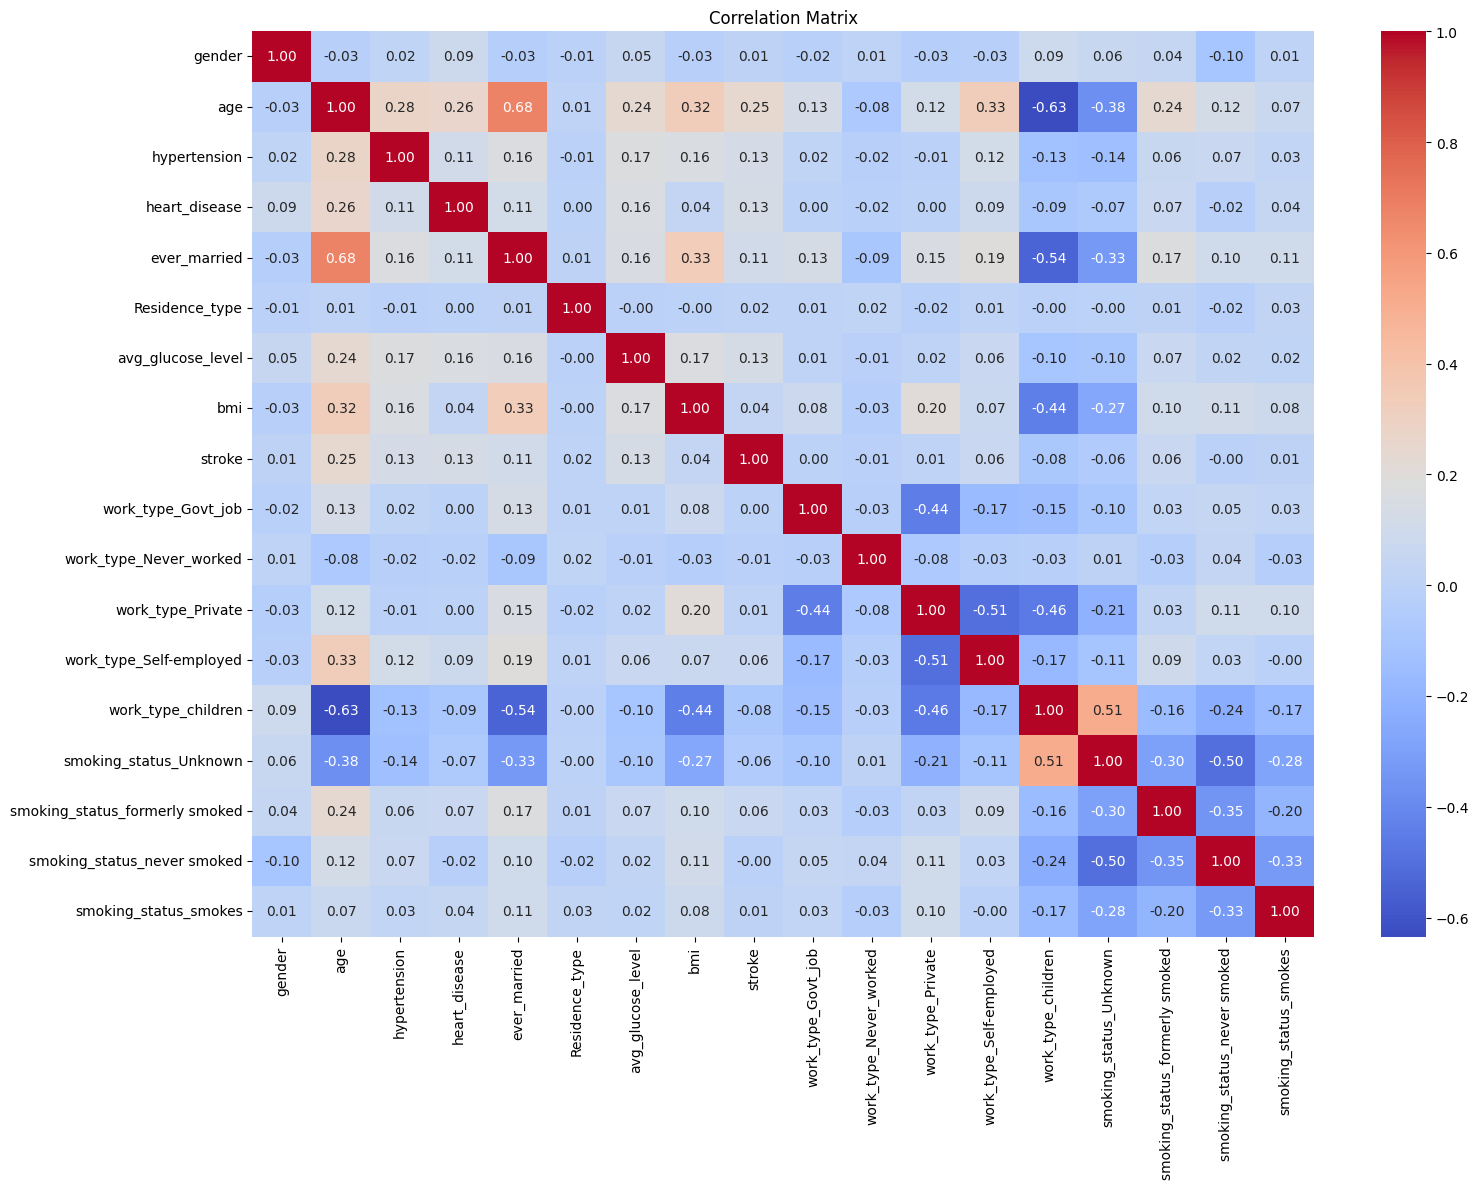

In [73]:
corr = df.corr()
print("Correlation matrix:")
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()